# Statistics for Michel electron candidate (PDHD MC production New202508)

### Created by Shu, 202508---

#### To explore decay points distribution asymmetry along drift direction

<br />
<br />
<br />
<br />
<br />
<br />

## Explore PDS t0 anomaly:
#### Dataset only after TPC cuts && BEFORE wvf "merging"

In [142]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


opch = [] # wvf coin num--
t0 = [] # energy of candidates---


opchFiles = [
    './pdsStat/opch_0809_and_0811.txt',
    './pdsStat/opch_0819_and_0820.txt'
]
for file_path in opchFiles:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                opch.append(float(value))


t0Files = [
    './pdsStat/PDSt0_0809_and_0811.txt',
    './pdsStat/PDSt0_0819_and_0820.txt'
]
for file_path in t0Files:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                t0.append(float(value))

print("Length of opch : ", len(opch))
print("Length of PDSt0: ", len(t0))

                

Length of opch :  42987
Length of PDSt0:  42987


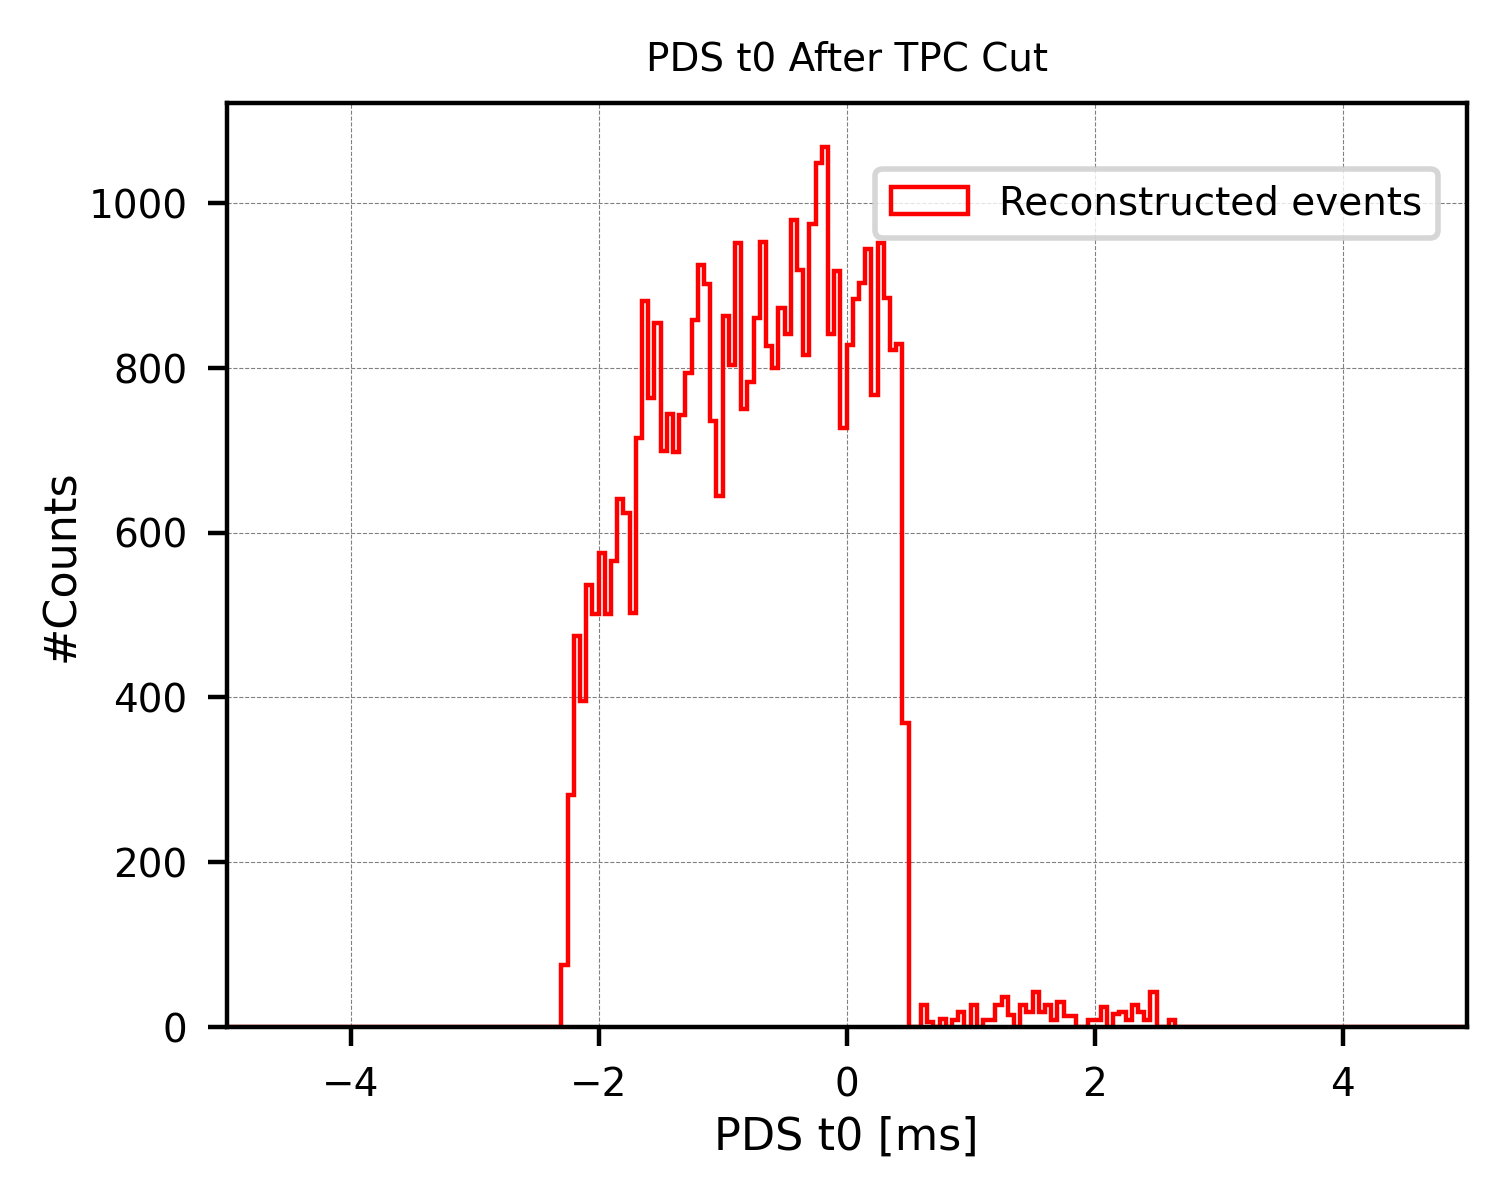

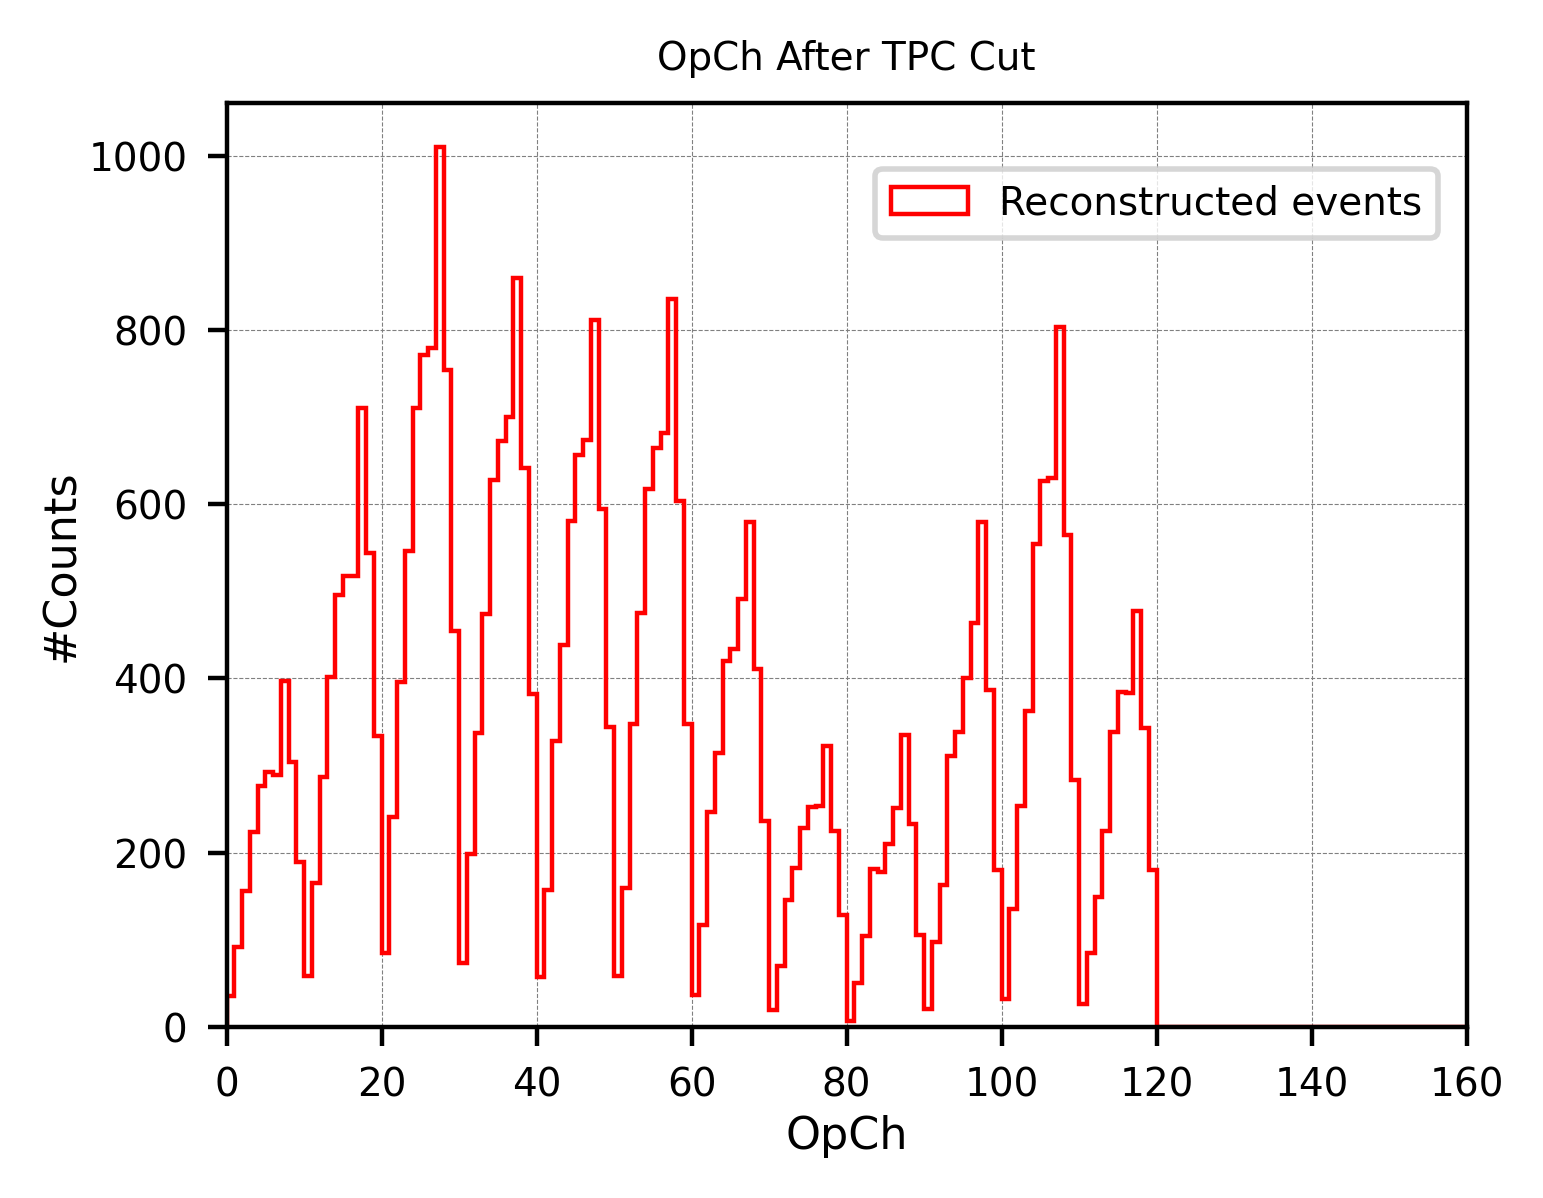

In [143]:

t0_ms = [value / 1000.0 for value in t0]


# Plotting the histogram PDS t0----------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.05
range_min = -5
range_max = 5
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(t0_ms, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label="Reconstructed events")

plt.xlim(-5, 5)
plt.xlabel('PDS t0 [ms]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 150)
#plt.yscale('log')
plt.title('PDS t0 After TPC Cut', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 








# Plotting the histogram OPCH----------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 160
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(opch, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label="Reconstructed events")

plt.xlim(0, 160)
plt.xlabel('OpCh', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 150)
#plt.yscale('log')
plt.title('OpCh After TPC Cut', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [146]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


coinNum = [] # wvf coin num--
coinTrueE = [] # energy of candidates---

file_list = [
    "./pdsStat/print_wvfCoin_count20250809.txt",
    "./pdsStat/print_wvfCoin_count20250811.txt",
    "./pdsStat/print_wvfCoin_count20250819.txt",
    "./pdsStat/print_wvfCoin_count20250820.txt"
]
for fname in file_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        coinNum.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")


coinTrueE_file_paths = [
    './pdsStat/print_trueInfo20250809.txt',
    './pdsStat/print_trueInfo20250811.txt',
    './pdsStat/print_trueInfo20250819.txt',
    './pdsStat/print_trueInfo20250820.txt'
]
for file_path in coinTrueE_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                coinTrueE.append(float(value))





print("Track candidates (TPC cut)  : 6592")
print("Track candidates with NO wvf: 1007")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



print("\nLength of track coinTrueE: ", len(coinTrueE))



Track candidates (TPC cut)  : 6592
Track candidates with NO wvf: 1007
Number of track candidates  : 6631

Length of track coinTrueE:  6631


Purity of coinNum:  5976 / 6631 (90.12%)

Candidates with #opWvf>=5:  4721 / 6631 (71.20%)
Purity:  4201 / 4721 (88.99%)


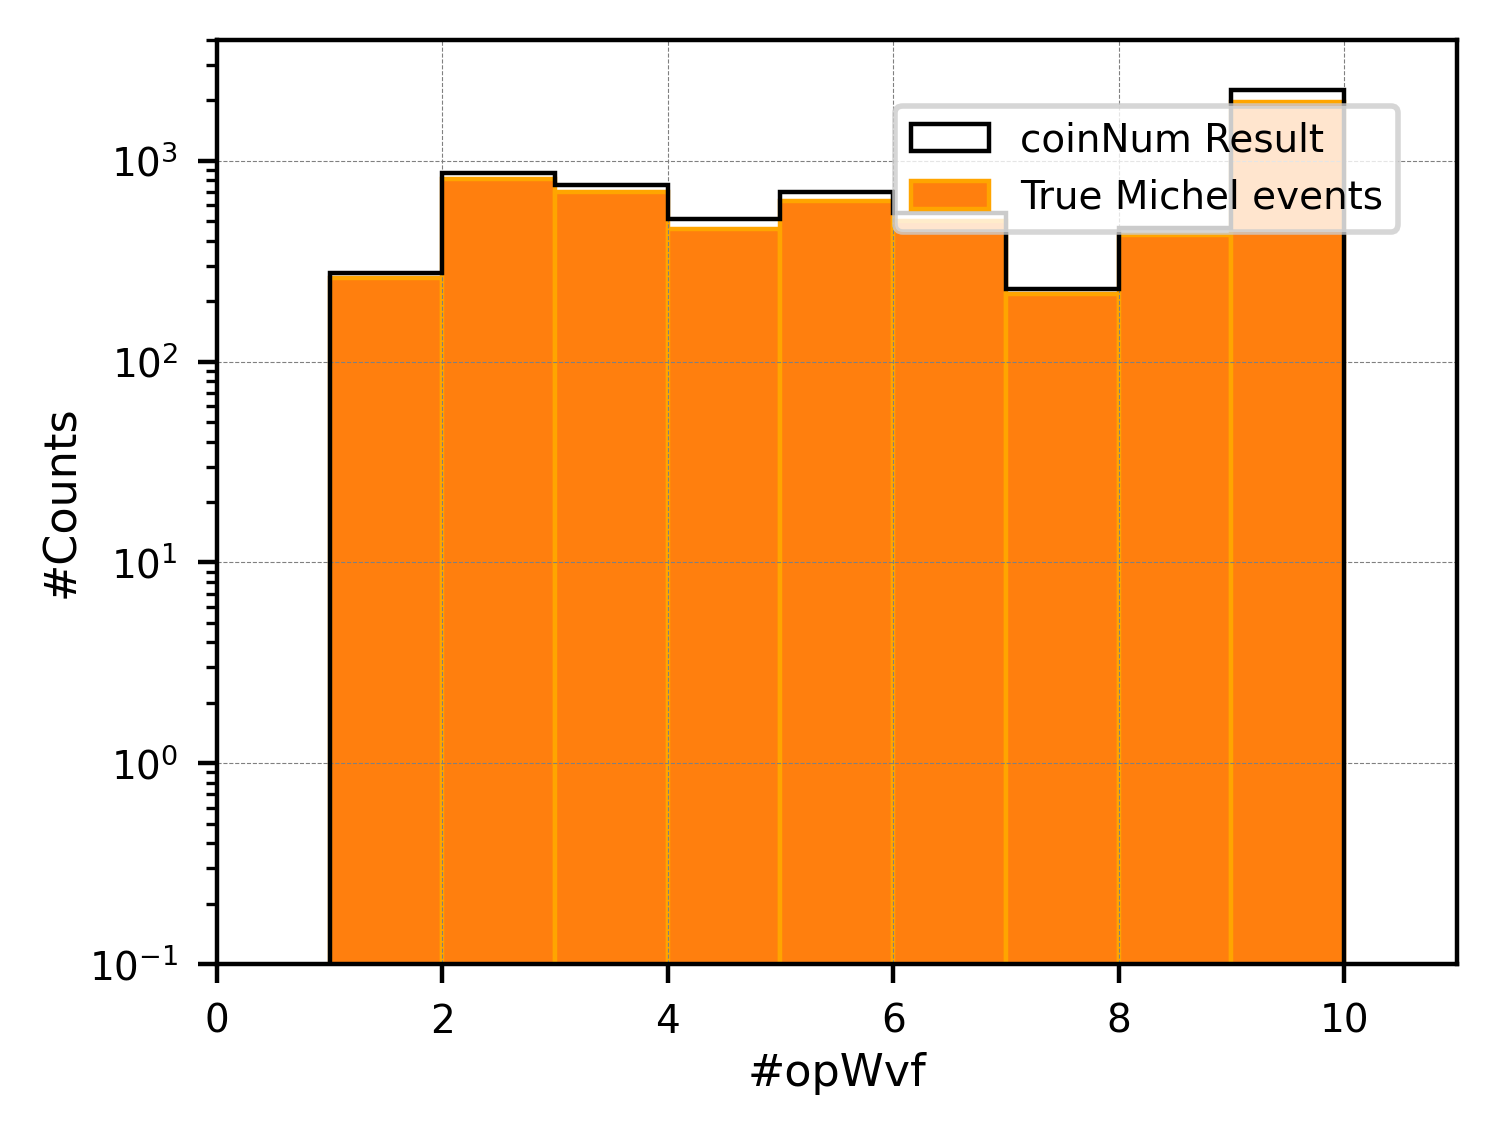

<Figure size 1600x1200 with 0 Axes>

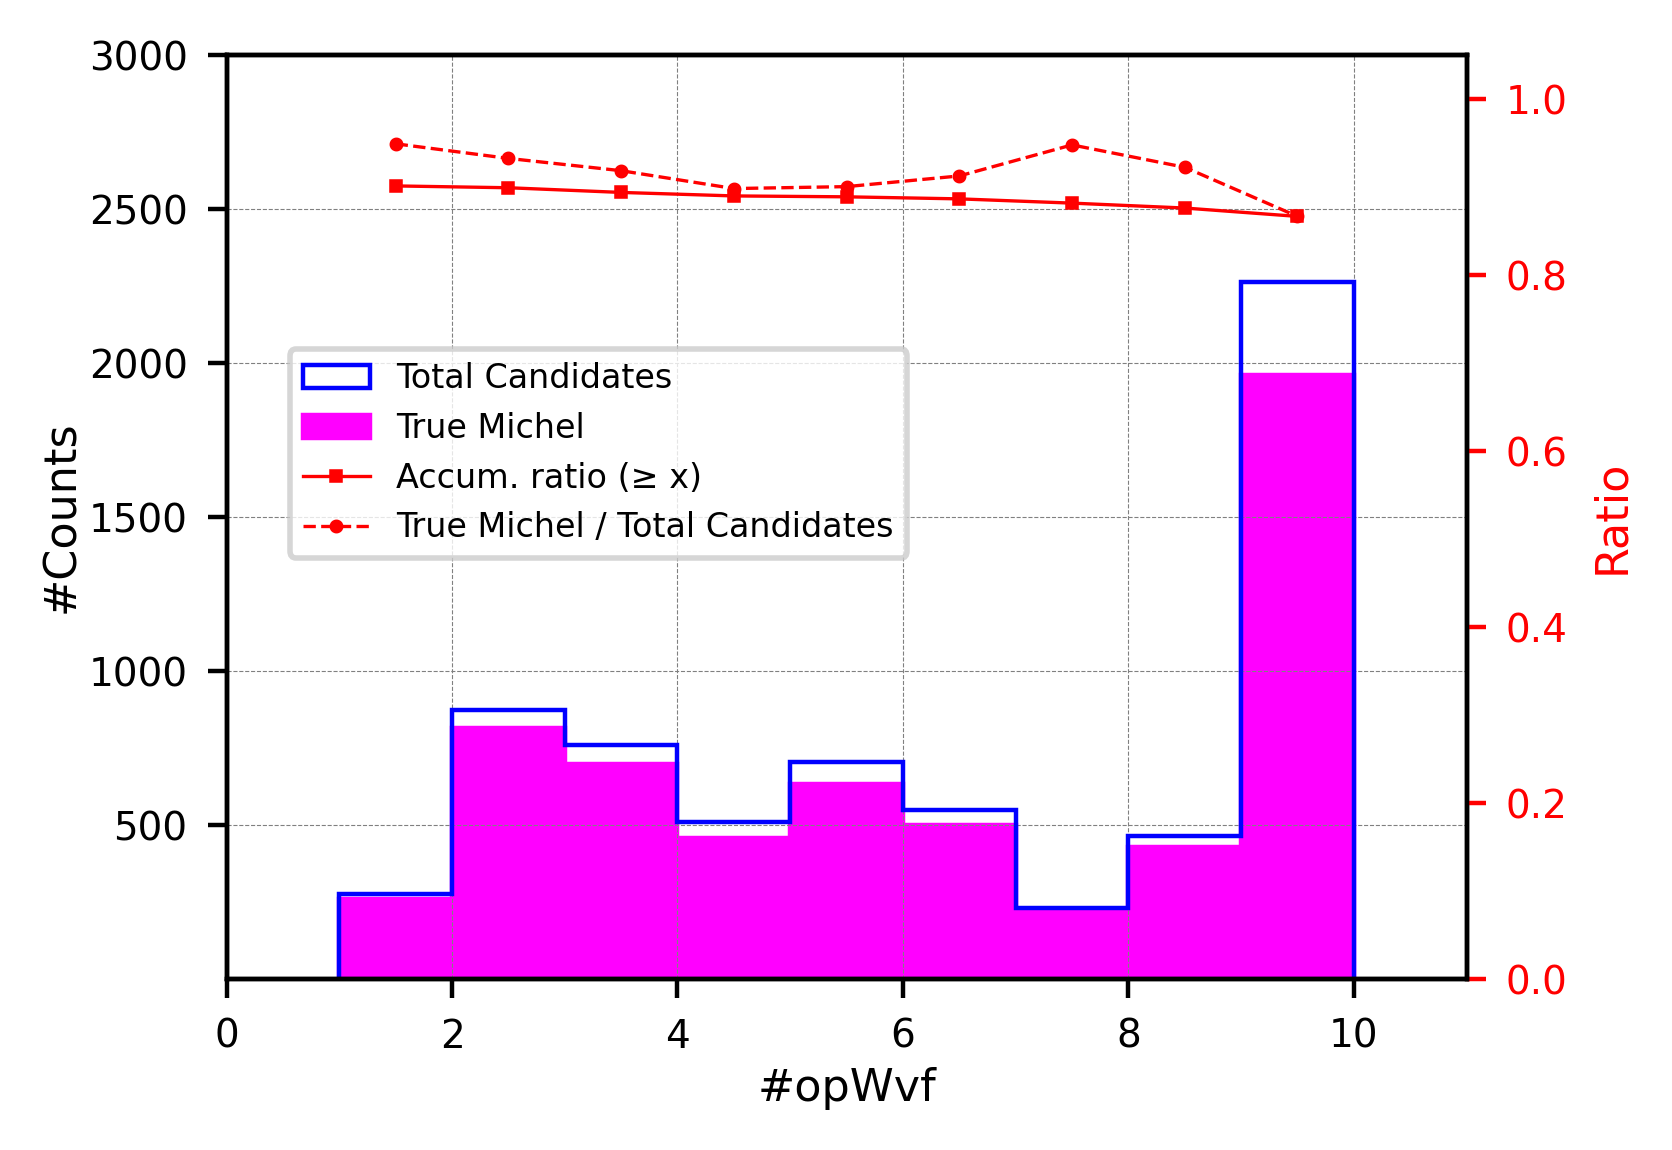

In [150]:

#Extract coinNum with trueE:===========================
coinNum_trueE = []
for i in range(0, len(coinTrueE)):
    count = coinNum[i]
    e = coinTrueE[i]

    if e > 0:
        coinNum_trueE.append(count)

print("Purity of coinNum: ", len(coinNum_trueE), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_trueE)/len(coinNum)*100))


#Apply preliminary cut #opWvf >=5:=====================
coinNum_cut5 = []
coinNum_trueE_cut5 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]
    trueE = coinTrueE[i]

    if coin >=4:
        coinNum_cut5.append(coin)
    
        if trueE > 0:
            coinNum_trueE_cut5.append(trueE)

print("\nCandidates with #opWvf>=5: ", len(coinNum_cut5), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut5)/len(coinNum)*100))
print("Purity: ", len(coinNum_trueE_cut5), "/", len(coinNum_cut5), "({:.2f}%)".format(len(coinNum_trueE_cut5)/len(coinNum_cut5)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.plot([5, 5], [0, 1200], color="black", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')
plt.hist(coinNum_trueE, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
#plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 4000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 1
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(coinNum, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(coinNum_trueE, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', color='magenta', histtype='bar', 
         linewidth=0.8, label="True Michel")

ax1.set_xlim(0, 11)
ax1.set_xlabel('#opWvf', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.set_ylim(0.1, 3000)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0.0, 1.05)

ax2.tick_params(axis='y', labelsize=7, colors='red')



# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.7),
           fontsize=9, ncol=1, prop={'size': 6})



plt.show()



<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4)

muon_time (TPC cut): 943
michel_time (TPC cut): 943
muon_intensity (TPC cut): 943
michel_intensity (TPC cut): 943
posX (TPC cut): 943
posY (TPC cut): 943
posZ (TPC cut): 943
energy (TPC cut): 943
lifetime (TPC cut): 943


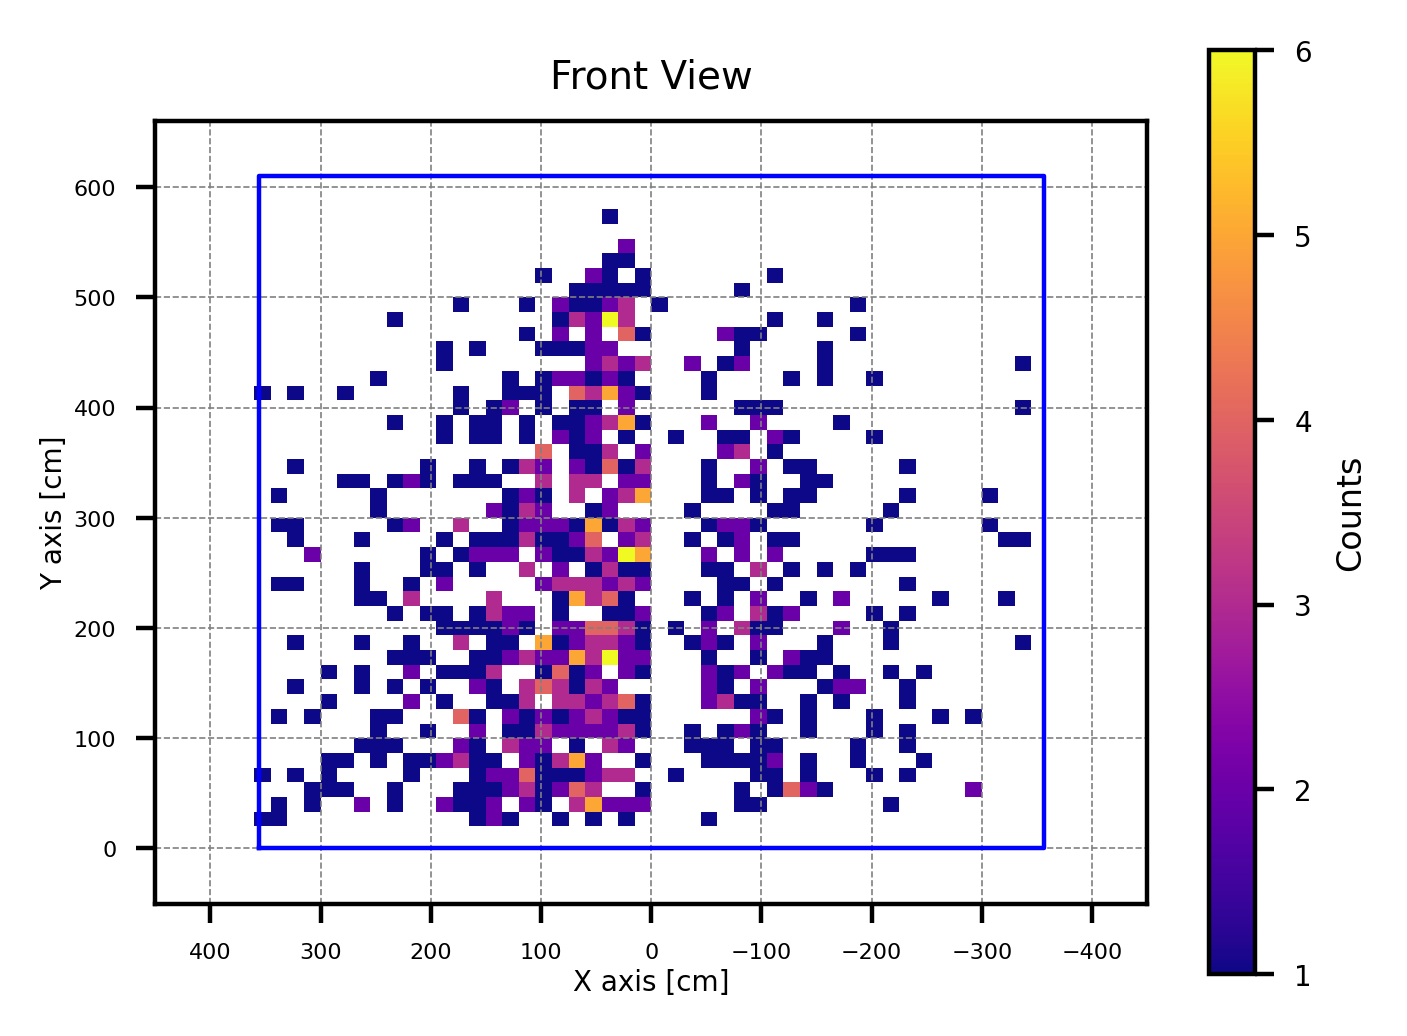

In [117]:
muon_time = []
michel_time = []
muon_intensity = []
michel_intensity = []
posX = []
posY = []
posZ = []
energy = []
lifetime = []













muon_time_list = [
    "./pdsStat/muon_time_20250809.txt",
    "./pdsStat/muon_time_20250811.txt",
]
for fname in muon_time_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        muon_time.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")



michel_time_list = [
    "./pdsStat/michel_time_20250809.txt",
    "./pdsStat/michel_time_20250811.txt",
]
for fname in michel_time_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        michel_time.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")



muon_intensity_list = [
    "./pdsStat/muon_intensity_20250809.txt",
    "./pdsStat/muon_intensity_20250811.txt",
]
for fname in muon_intensity_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = float(parts[1].strip())
                        muon_intensity.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")


michel_intensity_list = [
    "./pdsStat/michel_intensity_20250809.txt",
    "./pdsStat/michel_intensity_20250811.txt",
]
for fname in michel_intensity_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = float(parts[1].strip())
                        michel_intensity.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")



posX_file_paths = [
    './pdsStat/posX_extract_20250809.txt',
    './pdsStat/posX_extract_20250811.txt'
]
for file_path in posX_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                posX.append(float(value))



posY_file_paths = [
    './pdsStat/posY_extract_20250809.txt',
    './pdsStat/posY_extract_20250811.txt'
]
for file_path in posY_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                posY.append(float(value))


posZ_file_paths = [
    './pdsStat/posZ_extract_20250809.txt',
    './pdsStat/posZ_extract_20250811.txt'
]
for file_path in posZ_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                posZ.append(float(value))



energy_file_paths = [
    './pdsStat/energy_extract_20250809.txt',
    './pdsStat/energy_extract_20250811.txt'
]
for file_path in energy_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                energy.append(float(value))



lifetime_file_paths = [
    './pdsStat/lifetime_extract_20250809.txt',
    './pdsStat/lifetime_extract_20250811.txt'
]
for file_path in lifetime_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                lifetime.append(float(value))







print("muon_time (TPC cut):", len(muon_time))
print("michel_time (TPC cut):", len(michel_time))
print("muon_intensity (TPC cut):", len(muon_intensity))
print("michel_intensity (TPC cut):", len(michel_intensity))
print("posX (TPC cut):", len(posX))
print("posY (TPC cut):", len(posY))
print("posZ (TPC cut):", len(posZ))
print("energy (TPC cut):", len(energy))
print("lifetime (TPC cut):", len(lifetime))









#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(60, 60), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  238 (25.24%)
# of X >= 0:  705 (74.76%)

Michel purity:  828 /  943 (87.80%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 |   NaN
   -345.0 | 1.000
   -335.0 | 1.000
   -325.0 | 1.000
   -315.0 | 1.000
   -305.0 |   NaN
   -295.0 | 1.000
   -285.0 | 1.000
   -275.0 |   NaN
   -265.0 | 1.000
   -255.0 | 0.500
   -245.0 | 1.000
   -235.0 | 0.800
   -225.0 | 1.000
   -215.0 | 1.000
   -205.0 | 1.000
   -195.0 | 0.750
   -185.0 | 1.000
   -175.0 | 0.800
   -165.0 | 0.667
   -155.0 | 1.000
   -145.0 | 0.800
   -135.0 | 1.000
   -125.0 | 0.800
   -115.0 | 0.867
   -105.0 | 0.824
    -95.0 | 0.900
    -85.0 | 0.875
    -75.0 | 0.833
    -65.0 | 0.800
    -55.0 | 0.833
    -45.0 | 0.769
    -35.0 | 1.000
    -25.0 | 1.000
    -15.0 | 1.000
     -5.0 |   NaN
      5.0 | 0.923
     15.0 | 0.927
     25.0 | 0.926
     35.0 | 0.925
     45.0 | 0.887
     55.0 | 0.911
     65.0 | 0.878
     75.0 | 0.892
 

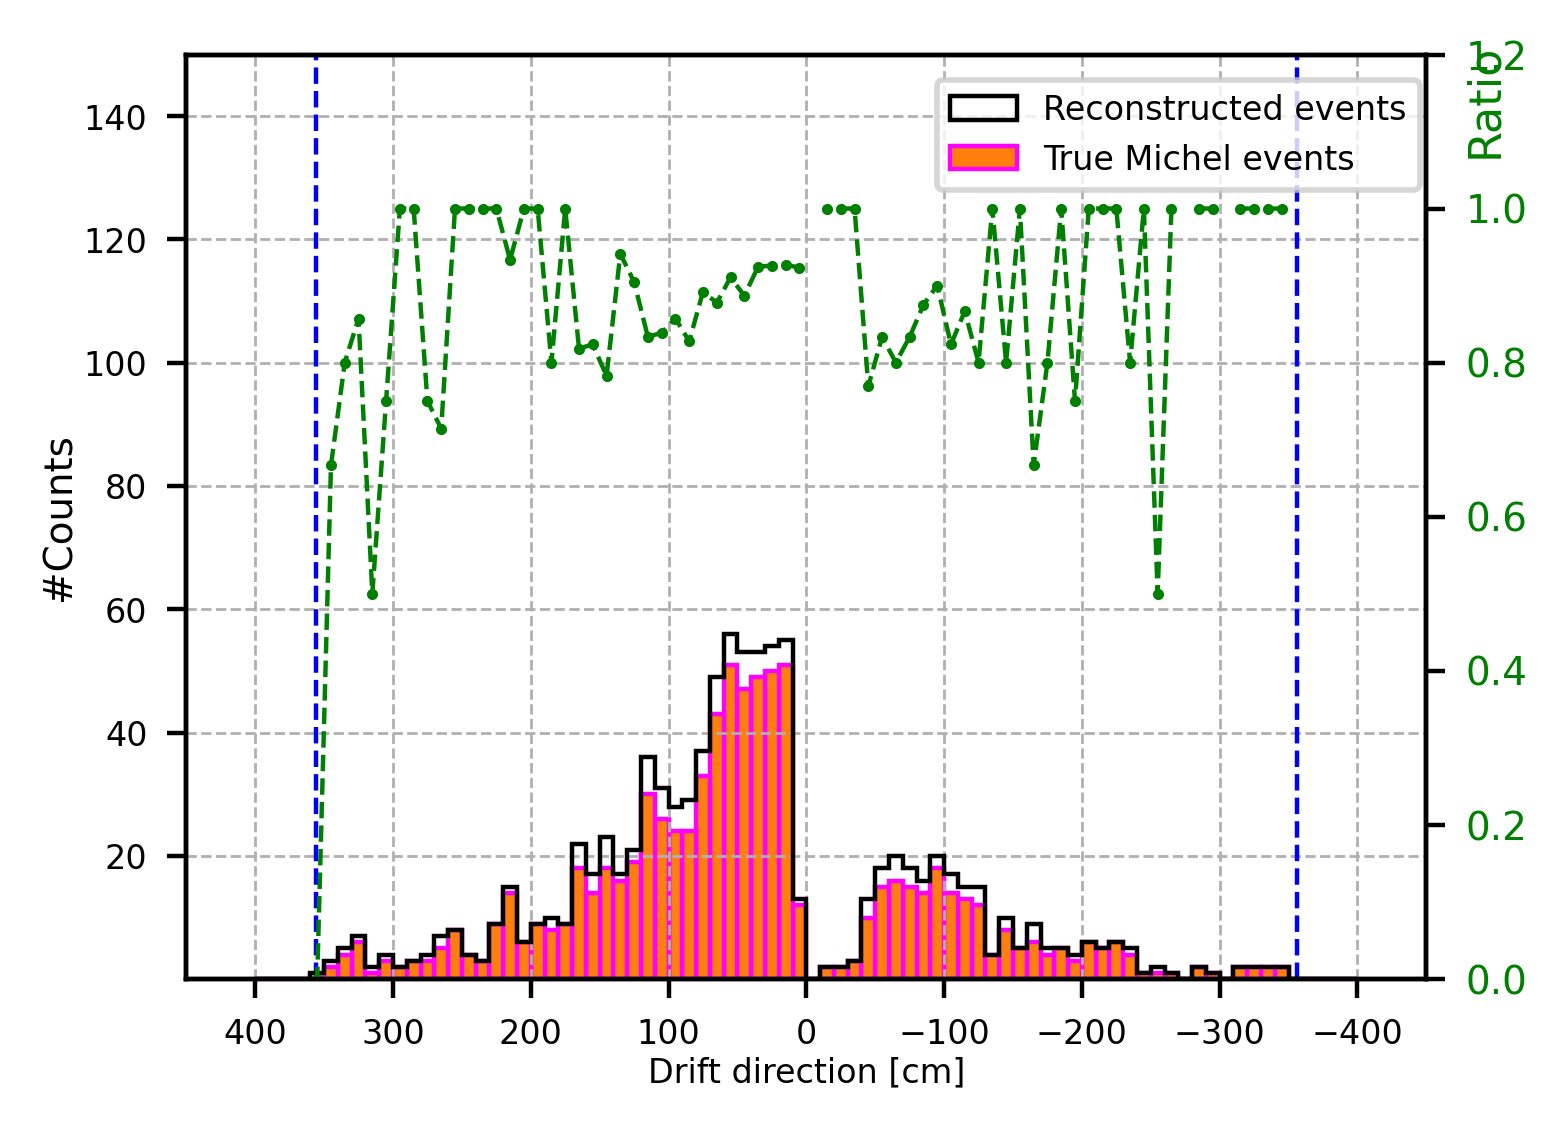

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





#Decay points distribution:==================================================================
print("Decay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))

posX_trueE = []
for i in range(0, len(energy)):
    e = energy[i]
    x = posX[i]
    if e > 0:
        posX_trueE.append(x)
        
print("\nMichel purity: ", len(posX_trueE), "/ ", len(posX), "({:.2f}%)".format(len(posX_trueE)/len(posX)*100)) 


# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(posX, bins=bins)
n_final, _ = np.histogram(posX_trueE, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='Reconstructed events')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='bar', linewidth=0.8, label='True Michel events')

ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-450, 450)
ax1.set_ylim(0.1, 150)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.invert_xaxis()
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)

# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o--', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=8, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.95)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

# Final layout
#plt.tight_layout()
plt.show()


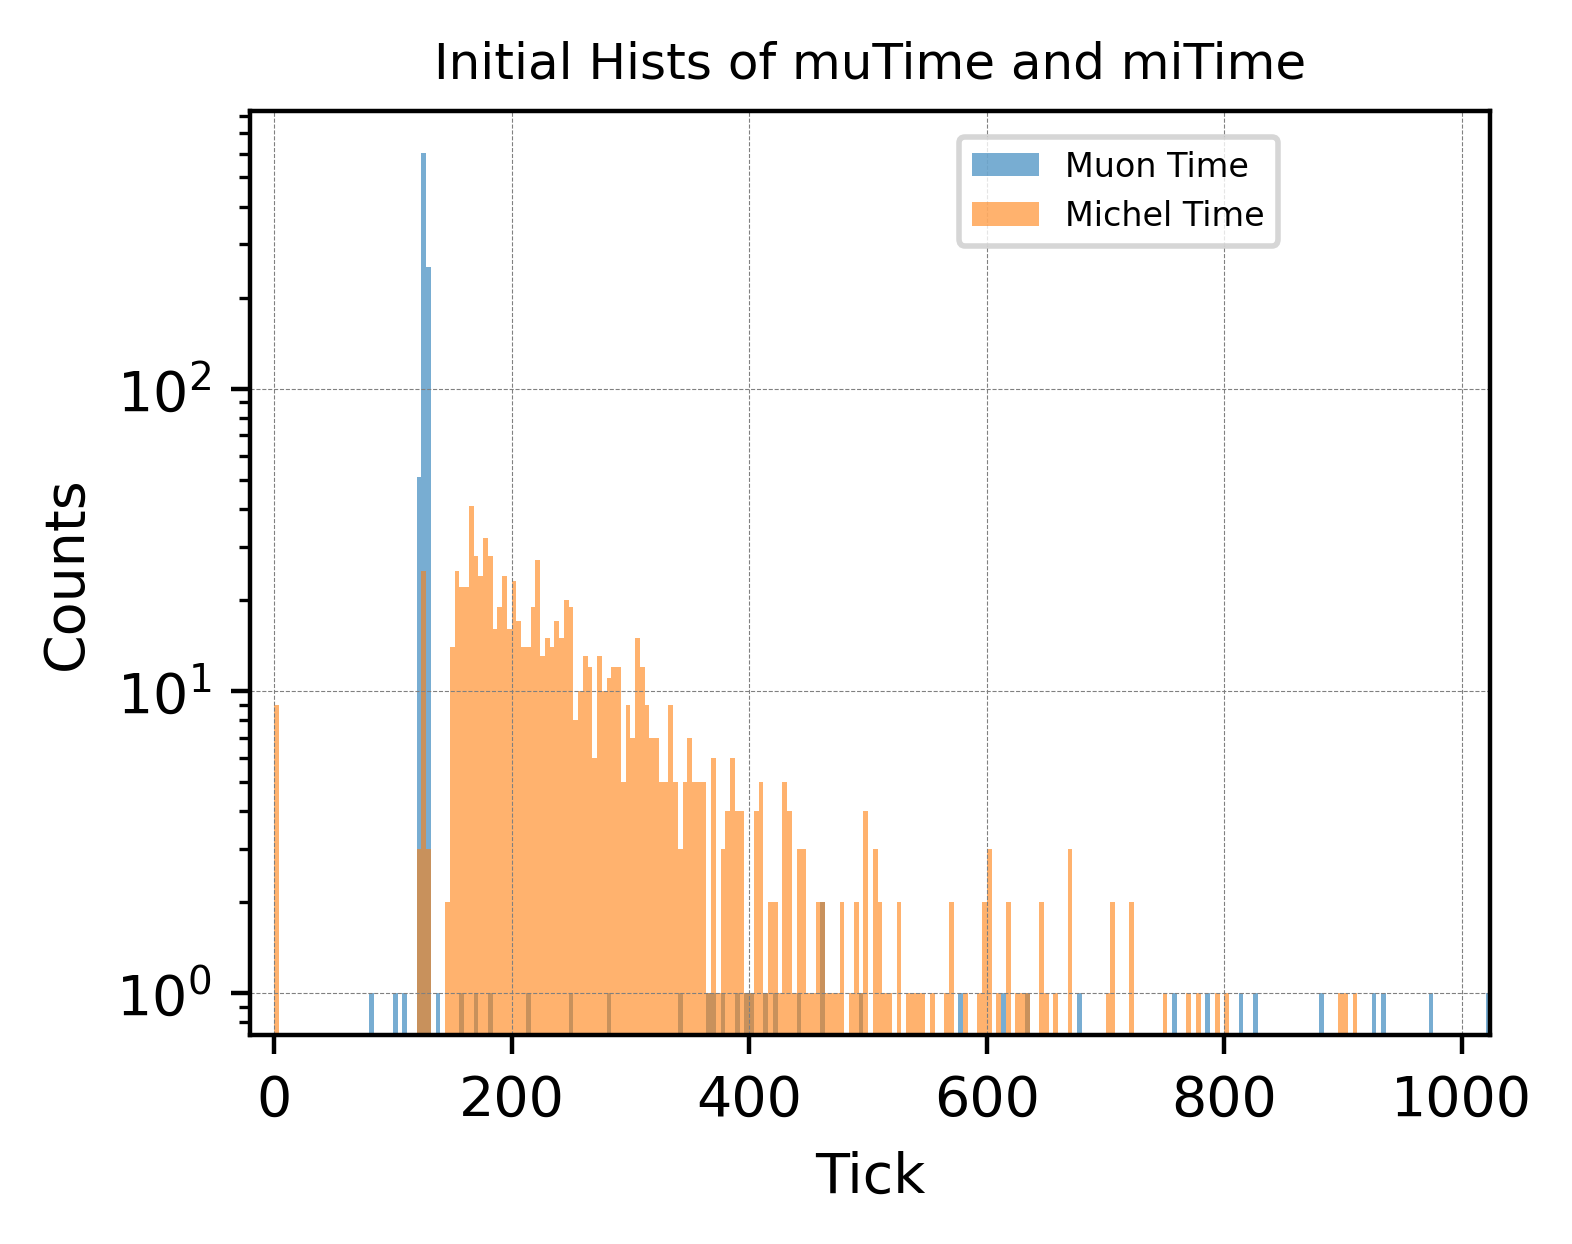

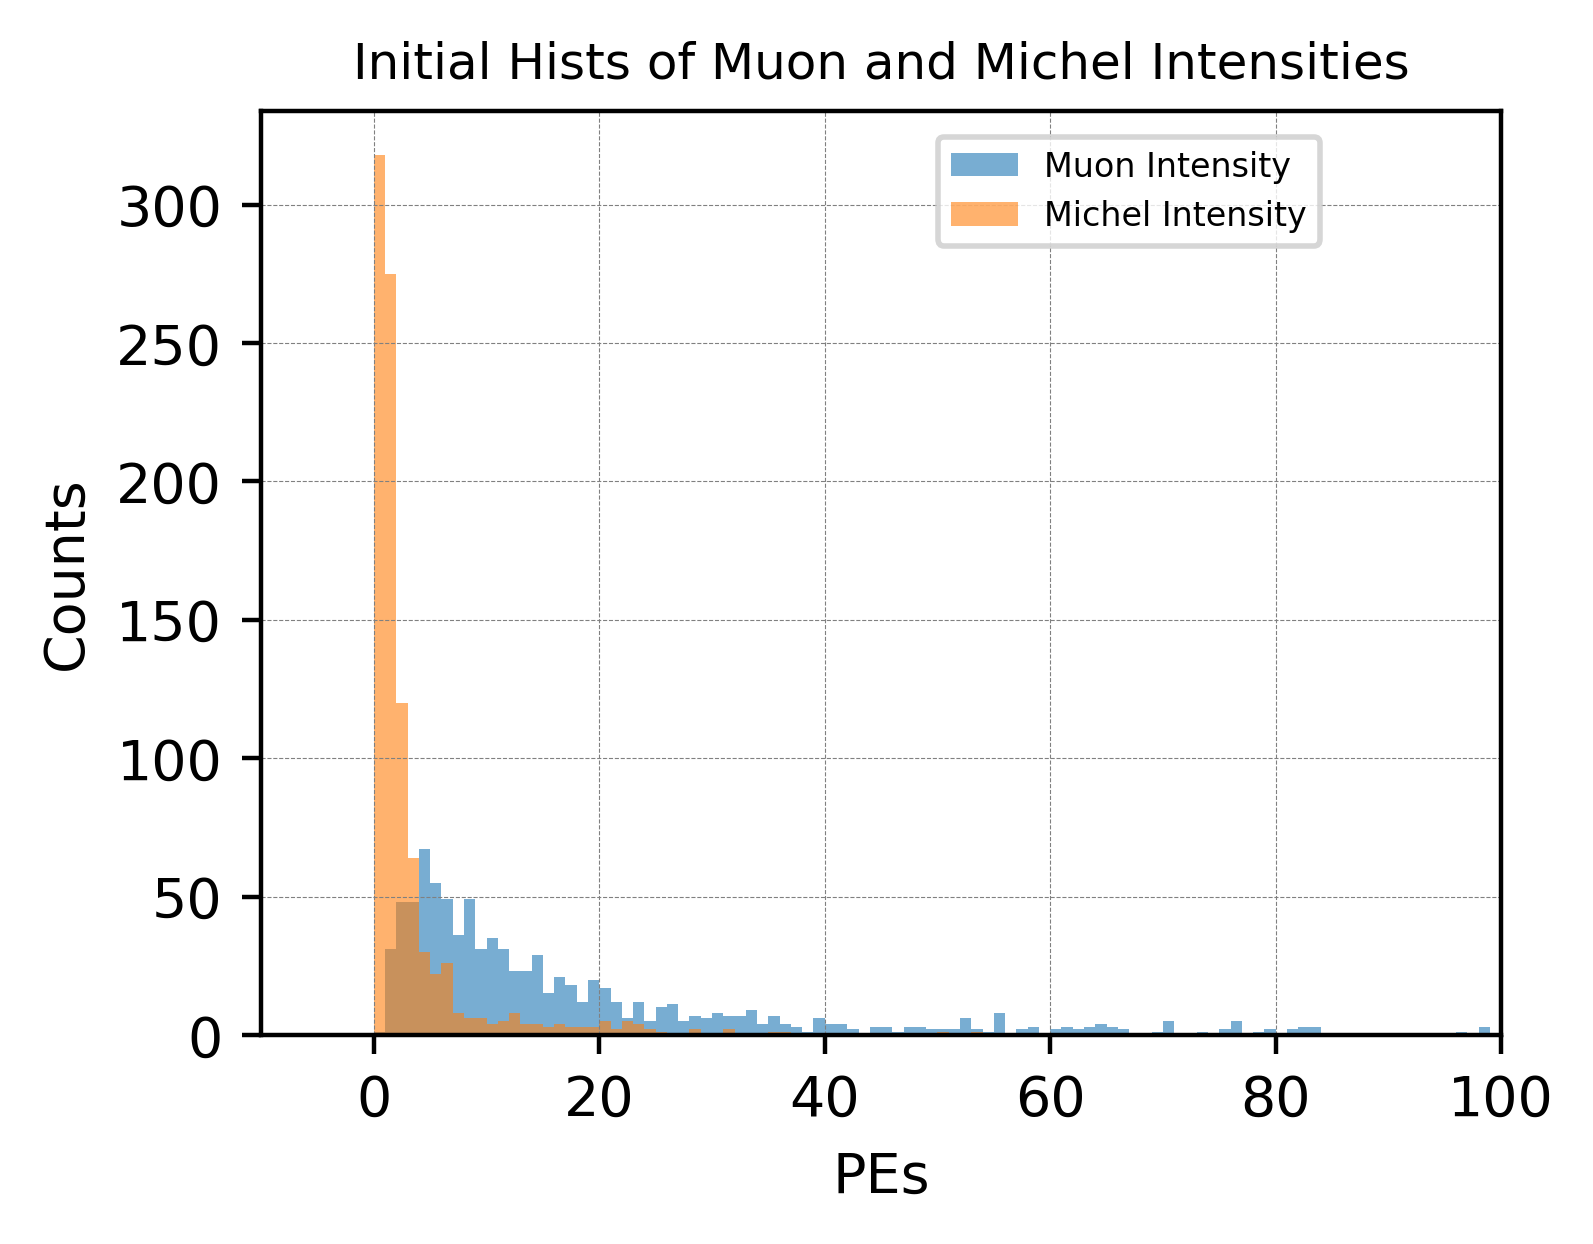

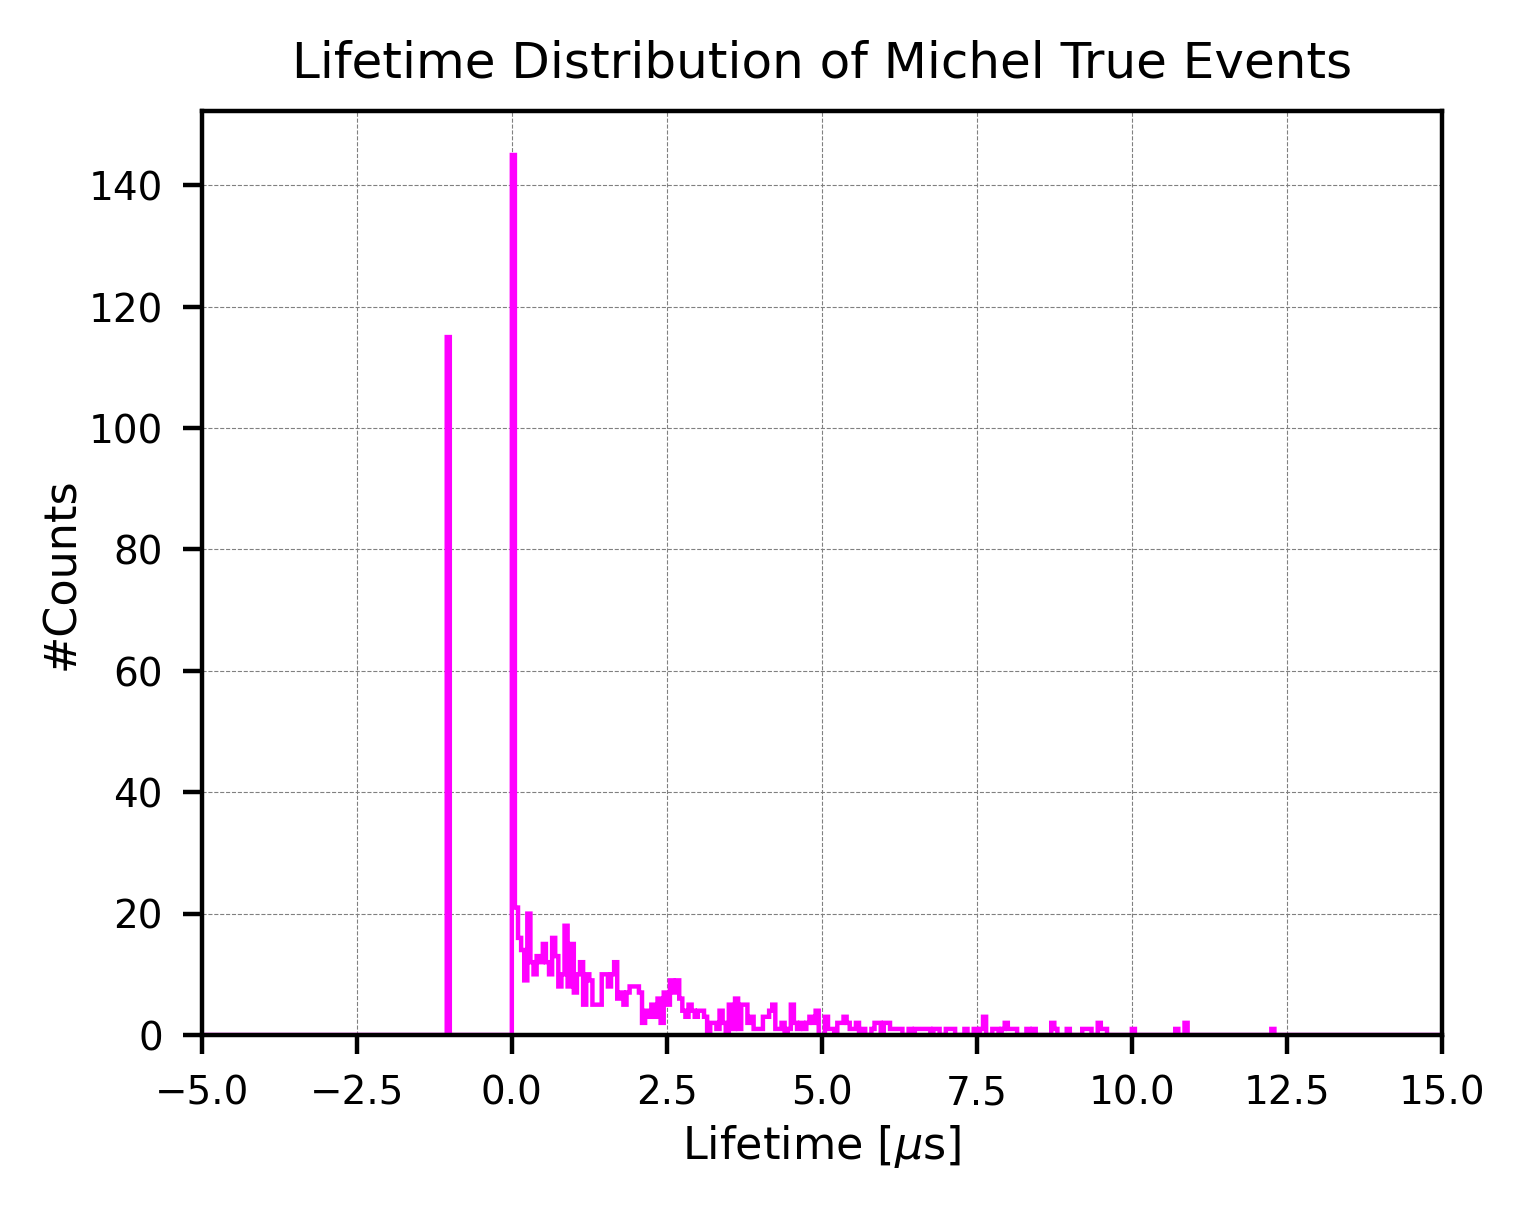

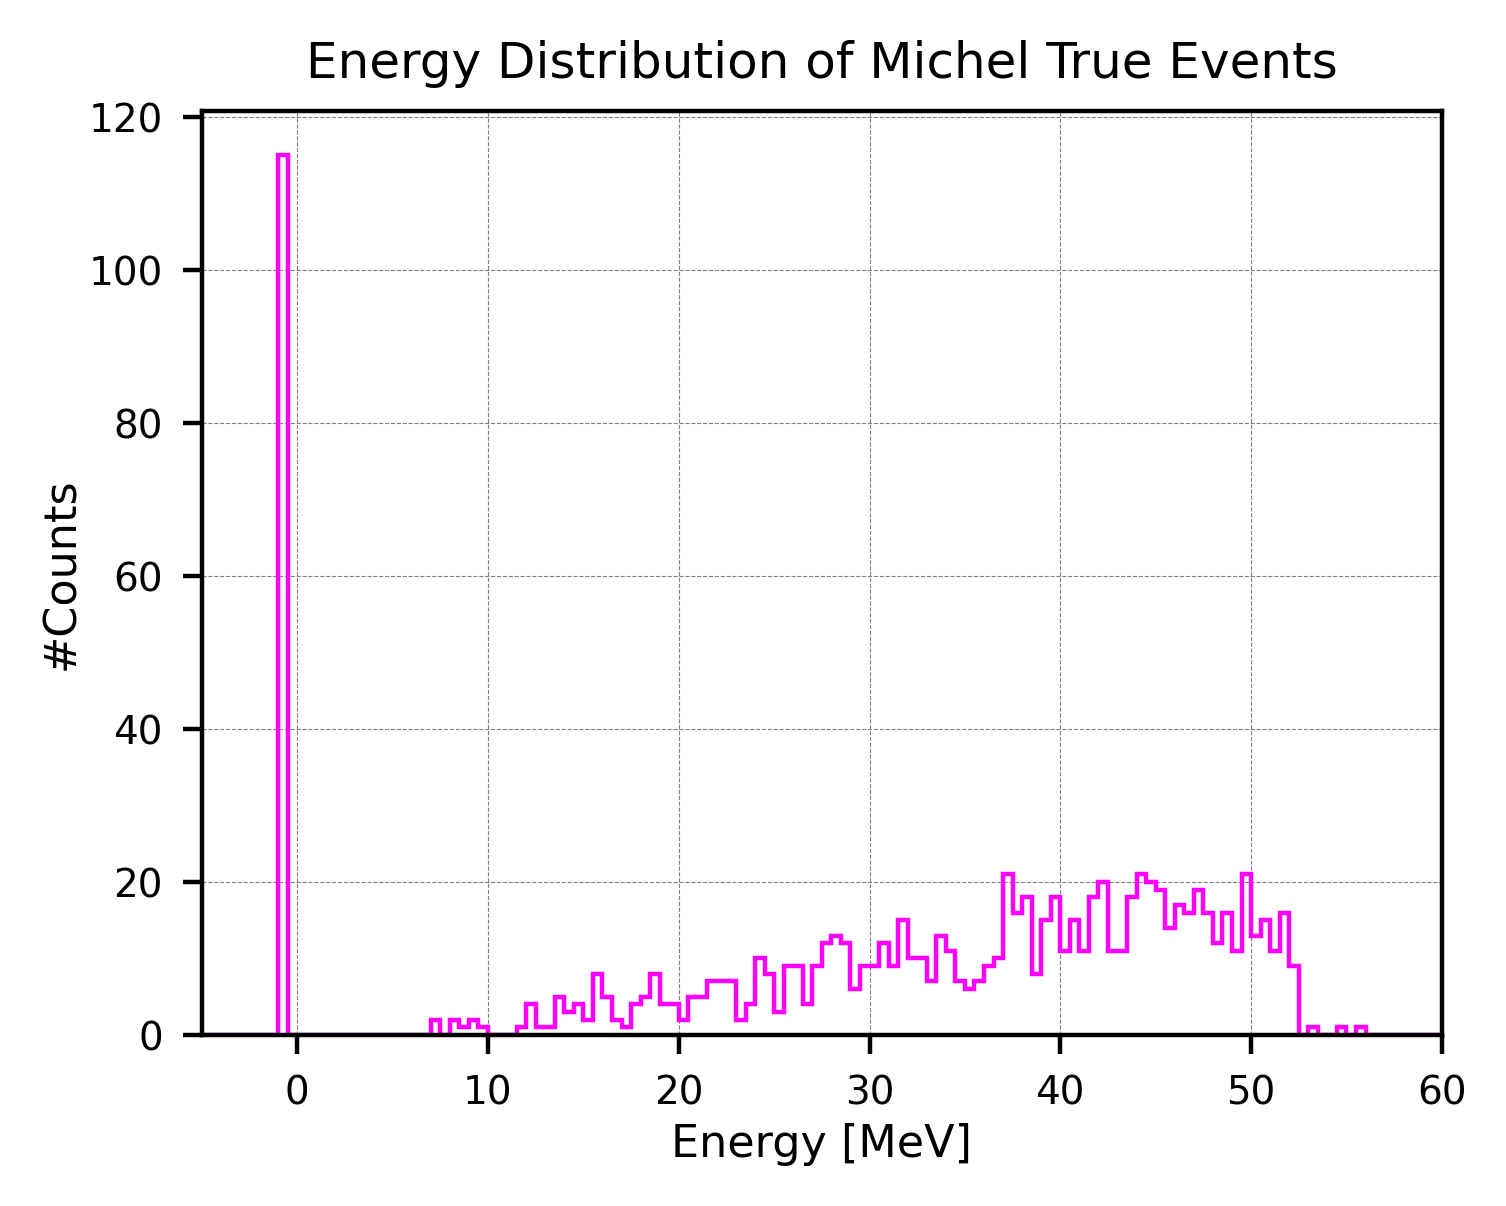

In [103]:
#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(lifetime, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 15)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(energy, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals (constrain muTime to [55, 65])


Muon events selection (mu peak constrained to [120, 130]):

Updated Muon events:  907 (96.18%)
Length of time_difference(Updated):  907

Length of updated decayX       :  907
Length of updated decayY       :  907
Length of updated decayZ       :  907
Length of updated energy       :  907
Length of updated lifetime     :  907

Michel purity:  796 /  907 (87.76%)


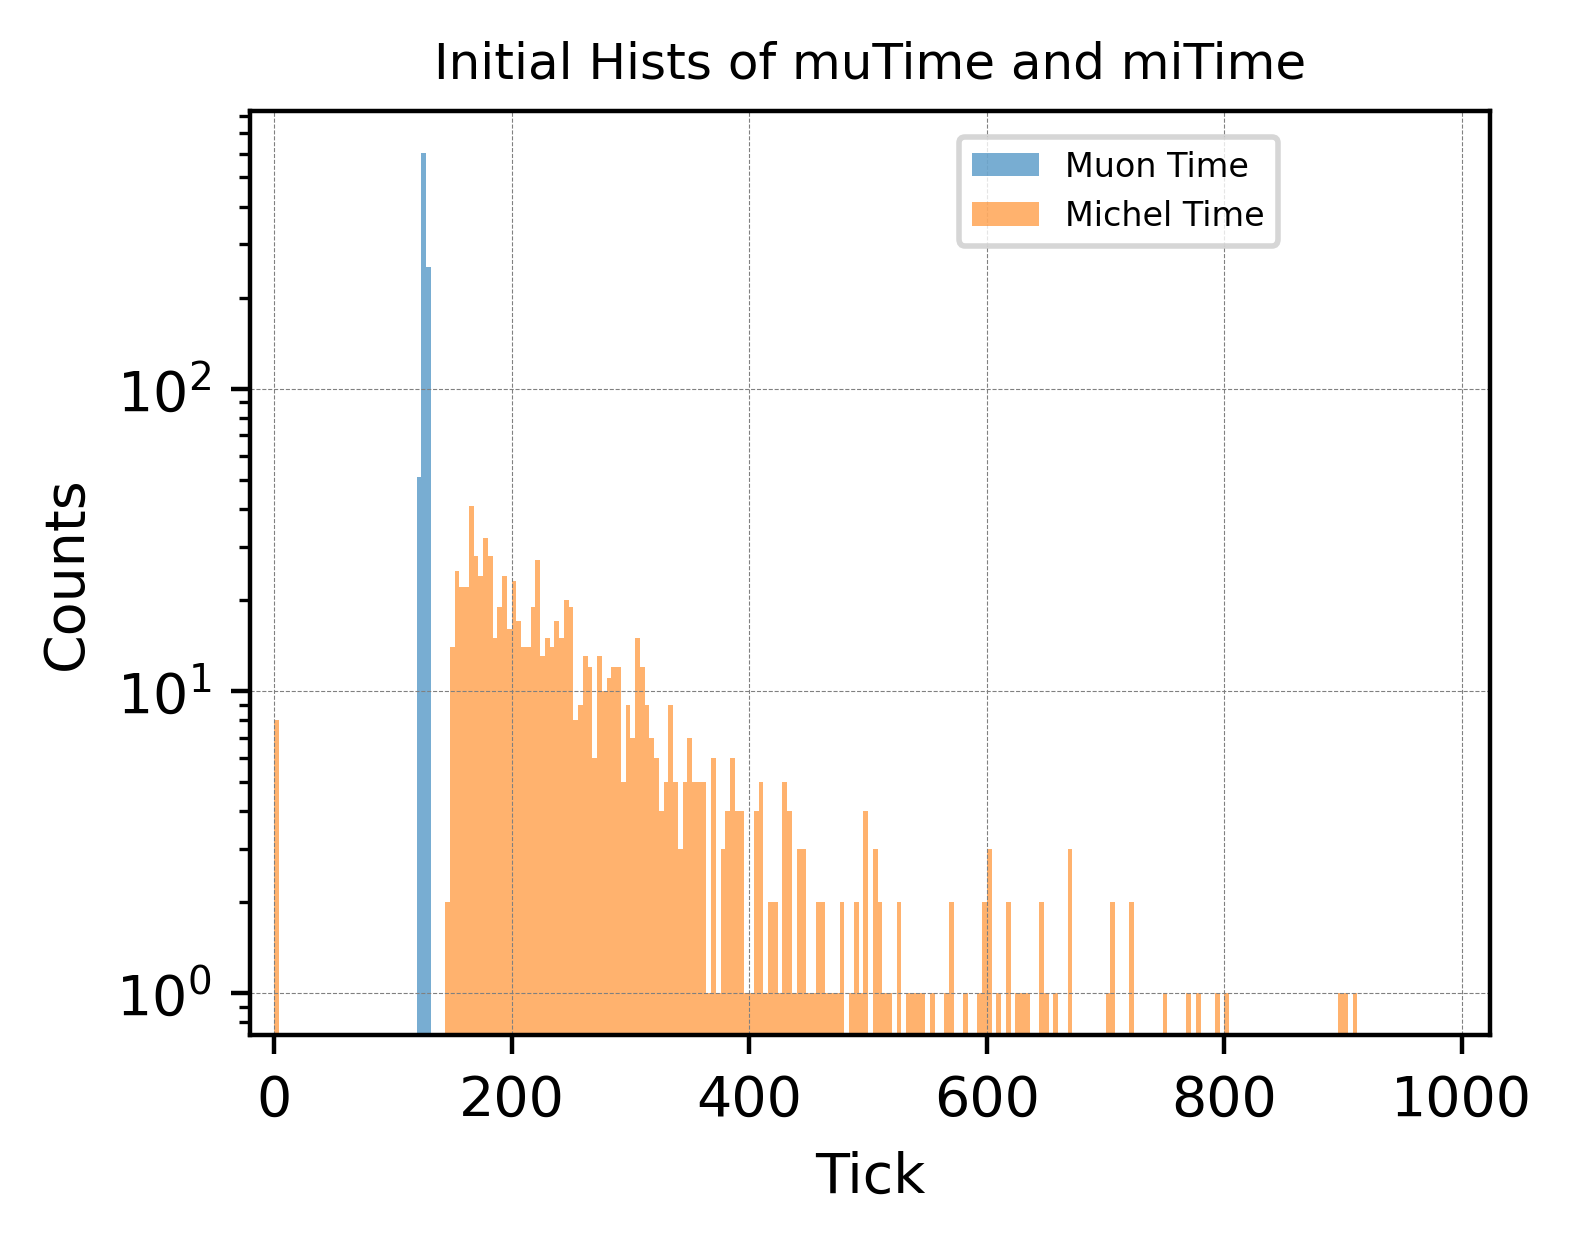




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  907


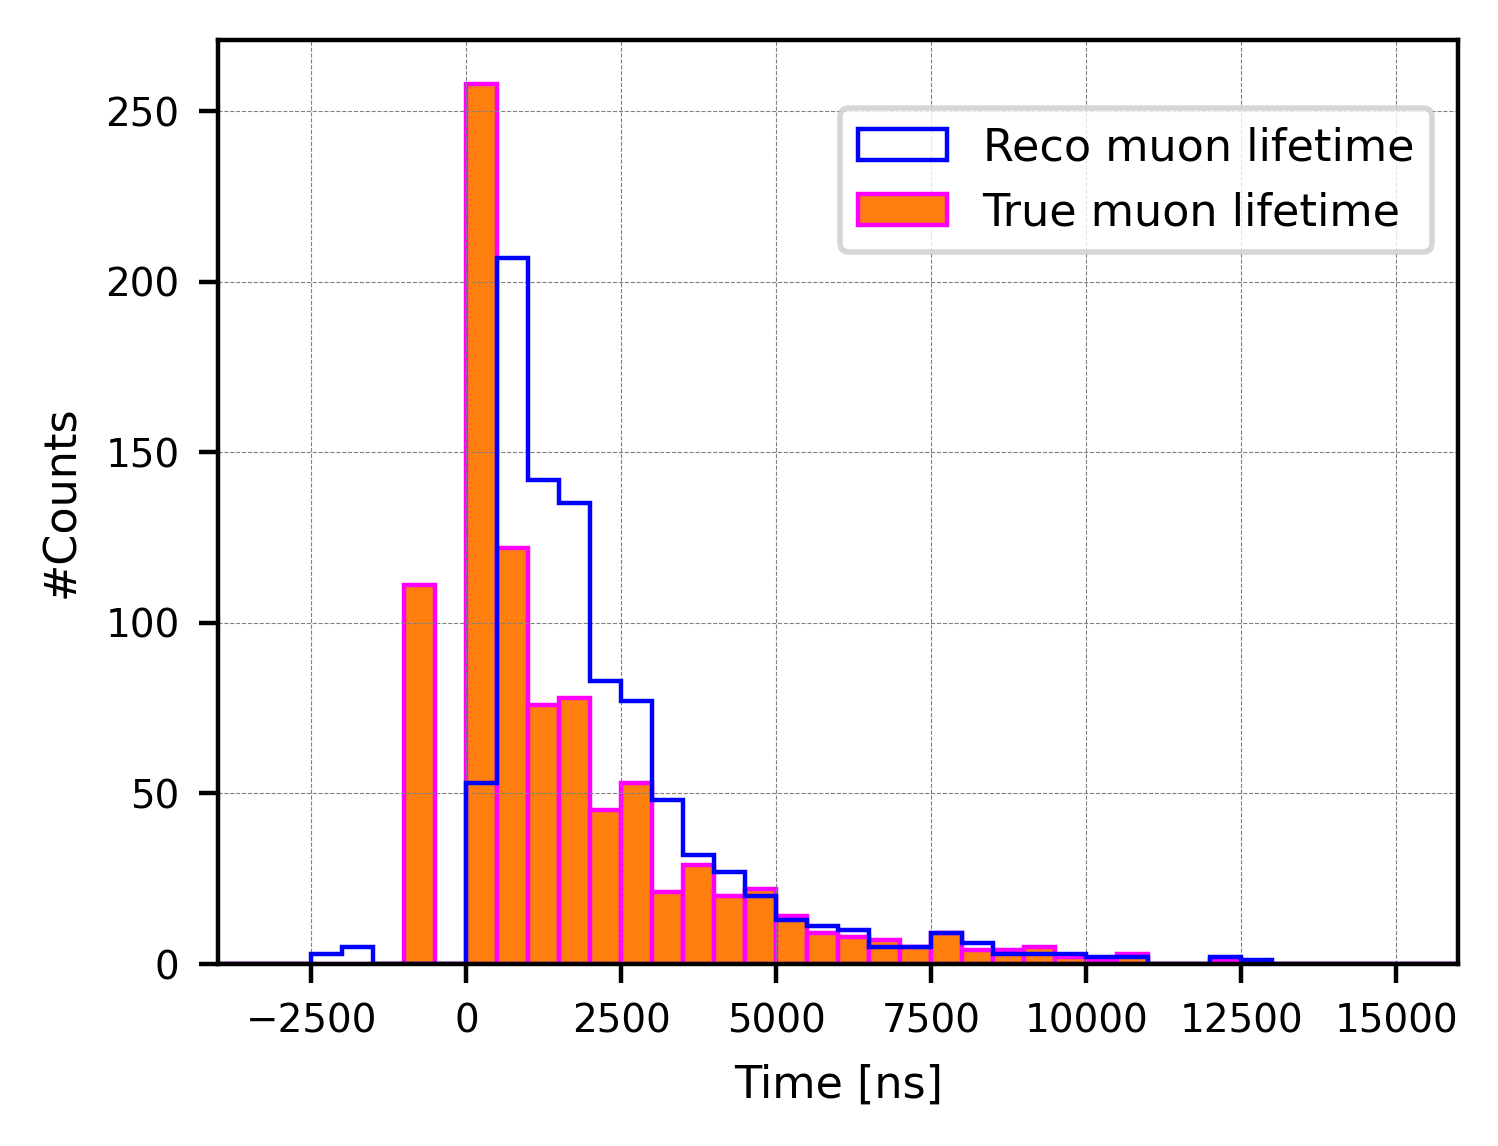

In [109]:
#Muon lifetime calculation-------------------------------------------------------------
# Only save muon time located in [55, 65]---
muTime_update = []
miTime_update = []
muIntensity_update = []
miIntensity_update = []
timdeDiff_update = []
decayX_update = []
decayY_update = []
decayZ_update = []
energy_update = []
lifetime_update = []

for i in range(0, len(muon_time)):
    muTime = muon_time[i]
    miTime = michel_time[i]
    muIntensity = muon_intensity[i]
    miIntensity = michel_intensity[i]
    x = posX[i]
    y = posY[i]
    z = posZ[i]
    e = energy[i]
    l = lifetime[i]

    if 120 <= muTime <= 130:
        muTime_update.append(muTime)
        miTime_update.append(miTime)
        muIntensity_update.append(muIntensity)
        miIntensity_update.append(miIntensity)
        timdeDiff_update.append(miTime-muTime)
        decayX_update.append(x)
        decayY_update.append(y)
        decayZ_update.append(z)
        energy_update.append(e)
        lifetime_update.append(l)

print("\nMuon events selection (mu peak constrained to [120, 130]):")
print("\nUpdated Muon events: ", len(muTime_update),
       "({:.2f}%)".format(len(muTime_update)/len(muon_time)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference(Updated): ", len(timdeDiff_update))

print("\nLength of updated decayX       : ", len(decayX_update))
print("Length of updated decayY       : ", len(decayY_update))
print("Length of updated decayZ       : ", len(decayZ_update))
print("Length of updated energy       : ", len(energy_update))
print("Length of updated lifetime     : ", len(lifetime_update))


#True e events---
trueE_updated = []
for i in range(0, len(energy_update)):
    e = energy_update[i]
    if e > 0:
        trueE_updated.append(3)
        
print("\nMichel purity: ", len(trueE_updated), "/ ", len(energy_update), "({:.2f}%)".format(len(trueE_updated)/len(energy_update)*100)) 






#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in timdeDiff_update]

lifetime_update_ns = [value * 1000 for value in lifetime_update]



print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='bar', linewidth=0.8,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



<br />
<br />
<br />
<br />


### Purification 2: remove events with unphysical lifetime (constrain lifetime to [0, inf))




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  899

# Purity (TRUE / reco):  788 / 899 (87.65%)


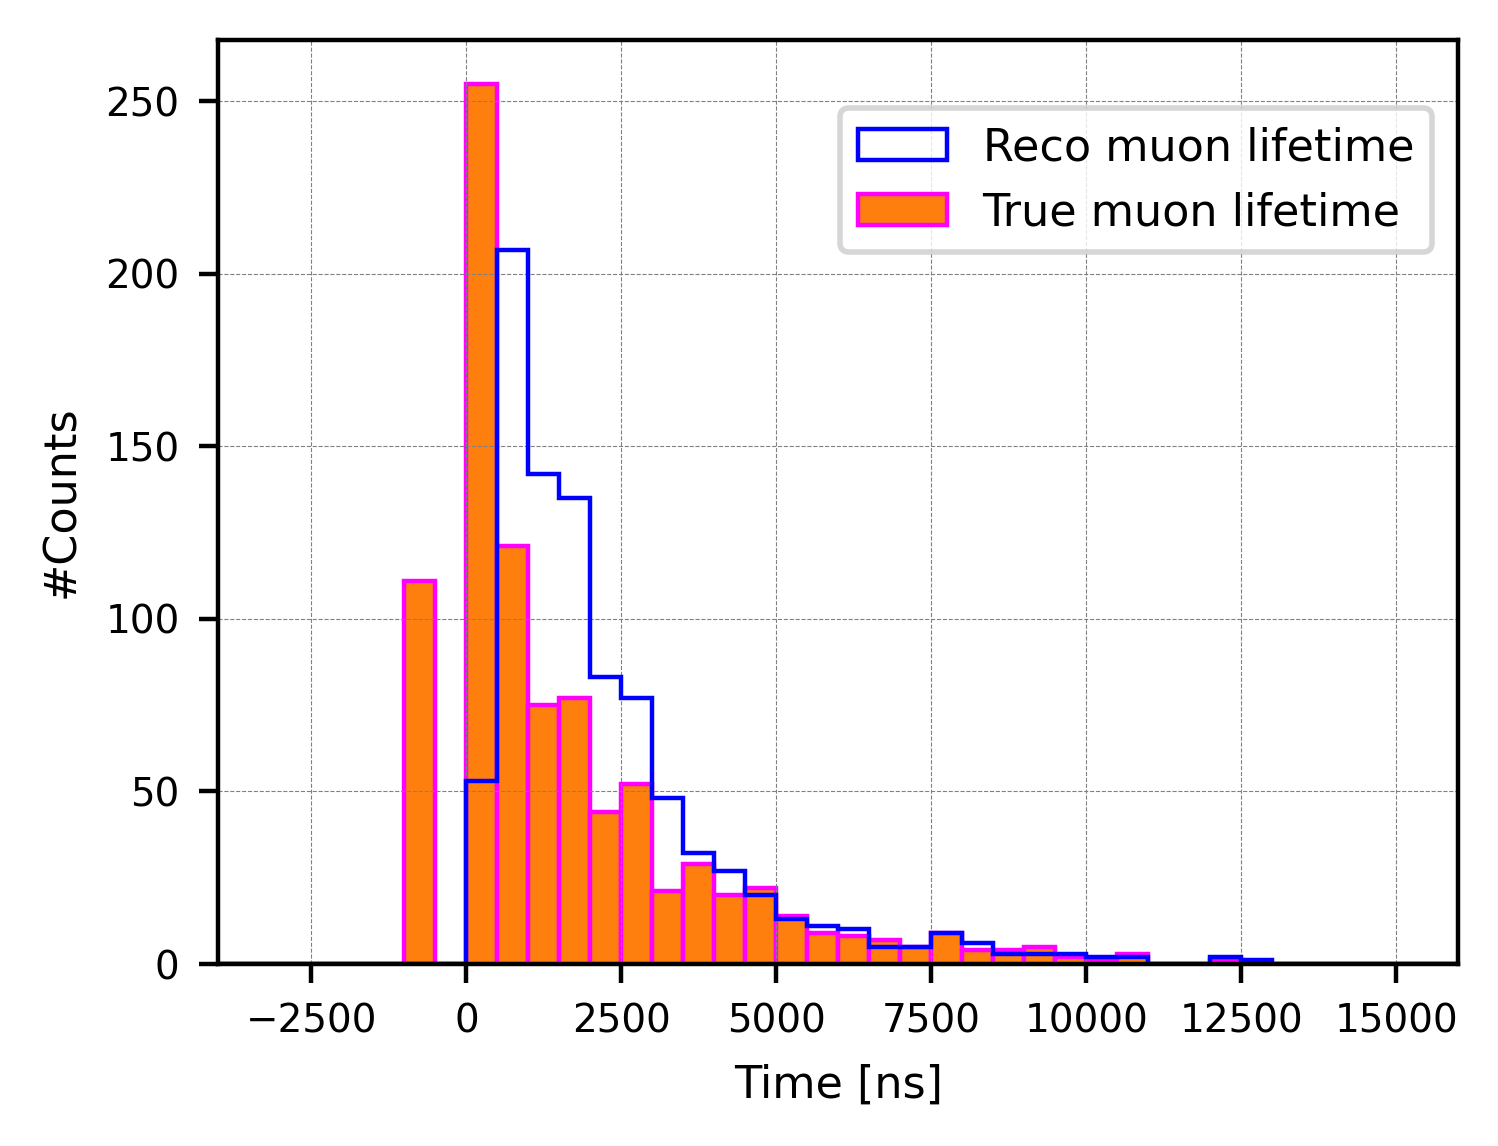

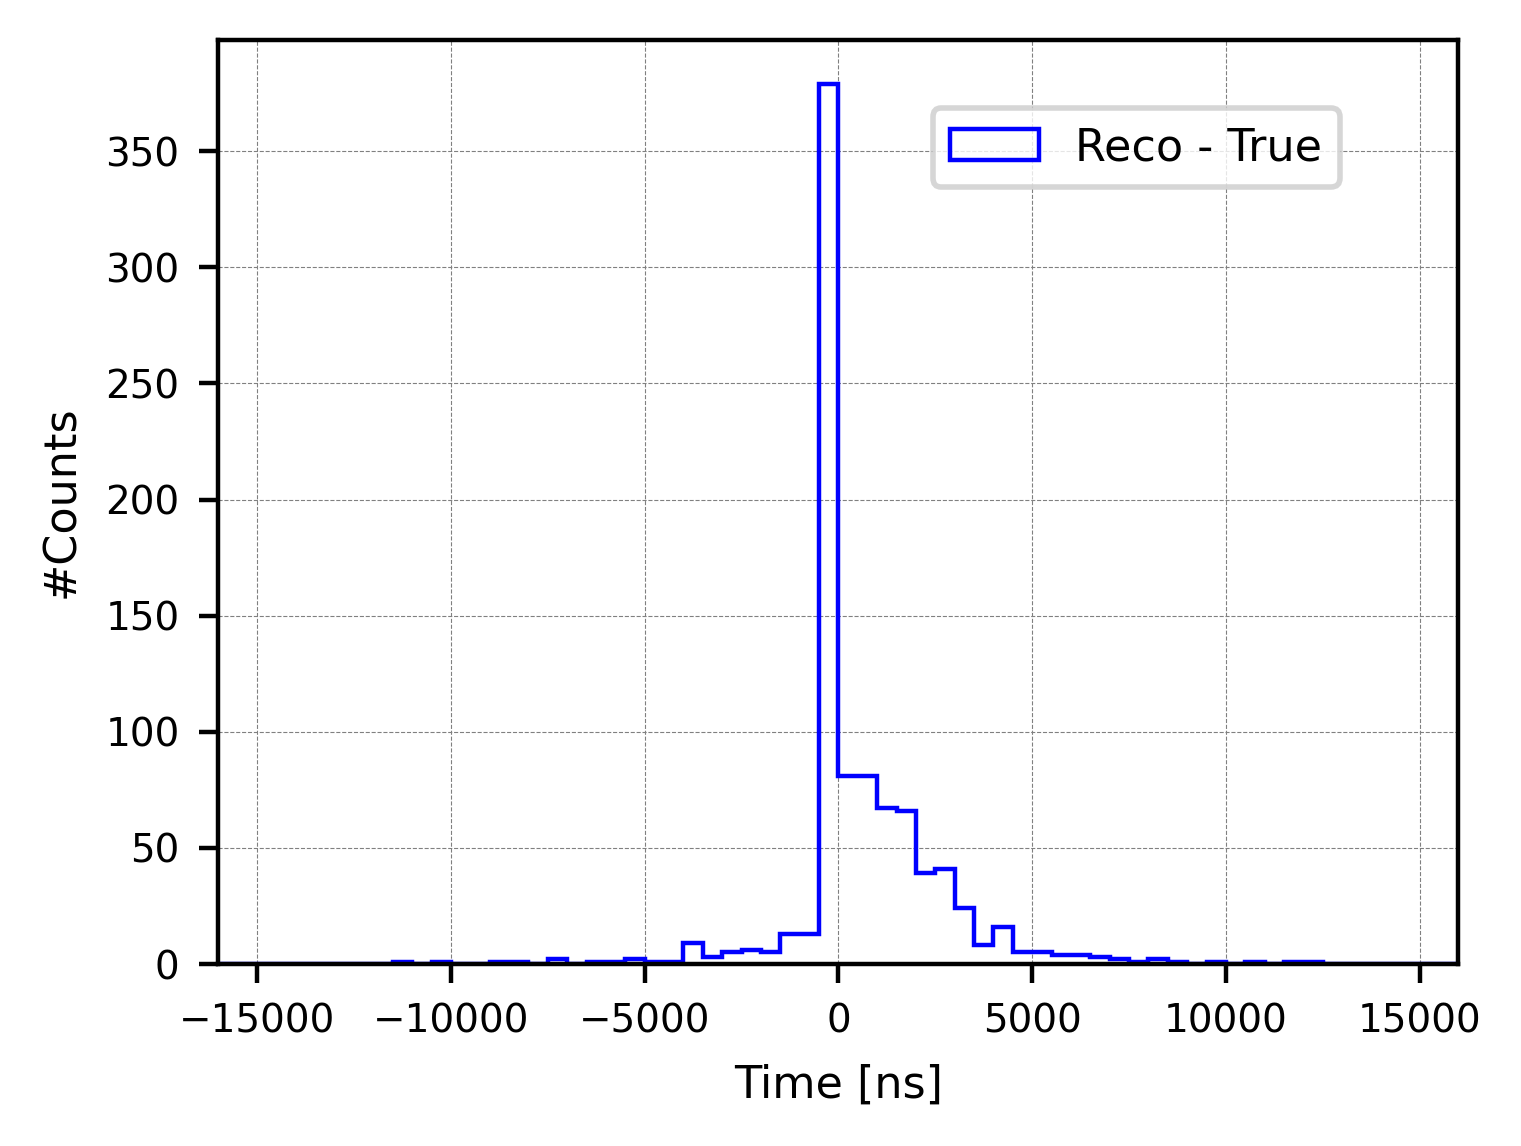

In [116]:
timdeDiff_update_ns2 = []
lifetime_update_ns2 = []


for i in range(0, len(timdeDiff_update_ns)):
    reco = timdeDiff_update_ns[i]
    true = lifetime_update_ns[i]

    if 0 <= reco:
        timdeDiff_update_ns2.append(reco)
        lifetime_update_ns2.append(true)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(timdeDiff_update_ns2))

purity_true = []
for i in range(0, len(lifetime_update_ns2)):
    true = lifetime_update_ns2[i]

    if true > 0:
        purity_true.append(true)
        
print("\n# Purity (TRUE / reco): ", len(purity_true), "/", len(lifetime_update_ns2), 
     "({:.2f}%)".format(len(purity_true)/len(lifetime_update_ns2)*100))




# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='bar', linewidth=0.8,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






#---------------------------------------------------------------
#Reco True difference-------------------------------------------

diff_reco_true = []
for i in range(0, len(timdeDiff_update_ns2)):
    reco = timdeDiff_update_ns2[i]
    true = lifetime_update_ns2[i]

    diff_reco_true.append(reco-true)


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Reco - True')



plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



